# Complementary category analysis

**What this notebook does.** It builds every co-purchase category pair Amazon's
`also_buy` lists trace out, scores each one by support and lift, and plots how
many pairs survive at every possible threshold on each metric.

**What it is used for.** Picking the two numbers. The pairs are far more than
the recommender can carry and most of them are thin, so they have to be cut
down — but a threshold is only defensible if you can see what it costs. Read
`MIN_EDGES` and `MIN_LIFT` off the curves here, then type them into
`categories.ipynb`, which applies them and writes the final table.

This notebook also saves the full scored table to `data/pair_stats.pkl`, which
is what makes that split possible: the expensive work — the 2.7 GB pickle and
the 2.1 GB catalogue CSV — happens here, once, and re-running the pipeline at a
different threshold then costs seconds.

The pipeline stages come from `categories.py`; only the charts
are defined here, since they exist to be looked at and adjusted rather than
reused.

In [1]:
import sys
from pathlib import Path

# Make the package importable when running from this folder
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from complementary_cats_pairs import (
    DST_COLS,
    NOT_IN_CATALOGUE,
    SRC_COLS,
    build_base_table,
    build_pairs,
    load_catalogue_lookup,
    load_taxonomy,
    save_pairs,
    score_pairs,
)

DATA_DIR = PROJECT_ROOT / "data"
FEATURES_PATH = DATA_DIR / "df_features.pkl"
CATALOGUE_PATH = DATA_DIR / "meta_Home_and_Kitchen_filtered.csv"
TAXONOMY_PATH = DATA_DIR / "category_taxonomy.json"
PAIR_STATS_PATH = DATA_DIR / "pair_stats.pkl"

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the extracted features

`df_features.pkl` is the raw metadata with the extraction results already
joined on, so loading it is what connects the categories and `also_buy` to the
features. It is the **source** side of every edge: `run_feature_extraction`
filters it to the categories that have a schema, so it holds only those items.

**`also_buy` must be in the pickle.** It only reaches `df_features.pkl` if the
extraction ran against a CSV that already carried the column — one rebuilt by
`data/variable_selection.ipynb` after `also_buy` was added to `fields_to_keep`.
`build_base_table` in §2 raises with that message if it is missing.

In [2]:
df_features = pd.read_pickle(FEATURES_PATH)

print(f"df_features   : {df_features.shape[0]:,} rows x {df_features.shape[1]} cols")
print(f"unique asins  : {df_features['asin'].nunique():,}")
print(f"cat_3 values  : {df_features['cat_3'].nunique():,} (the schema categories)")
df_features[["asin", "cat_2", "cat_3", "cat_4", "also_buy"]].head(3)

df_features   : 1,134,566 rows x 92 cols
unique asins  : 1,134,566
cat_3 values  : 69 (the schema categories)


,asin,cat_2,cat_3,cat_4,also_buy
0,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,"['B0001XR2F2', 'B01LY51HUN', 'B07CXZ9C5B', '03..."
1,0002020300,Home Dcor,Candles & Holders,Candles,[]
2,0006564224,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,[]


## 2. Clean `cat_4` and build the source side

`category_taxonomy.json` whitelists the `(cat_3, cat_4)` pairs that are real
categories rather than product bullets that leaked into the category path —
`'Imported'`, `'10" high'` and 550-odd others. A value is kept only if it is
valid under its own parent, since the same label can be real in one branch and
junk in another; everything else becomes `<cat_3>_Other`.

`build_base_table` applies that, parses `also_buy` back from its stringified
form, and pulls the first image url (high-res preferred). The same folding runs
over the catalogue lookup in §3, so both ends of an edge are cleaned
identically.

In [3]:
valid_pairs = load_taxonomy(TAXONOMY_PATH)
df_base = build_base_table(df_features, valid_pairs)

with_edges = int((df_base["also_buy_n"] > 0).sum())
folded = int(df_base["cat_4_clean"].str.endswith("_Other").sum())
print(f"valid (cat_3, cat_4) pairs: {len(valid_pairs):,}")
print(f"products                  : {len(df_base):,}")
print(f"folded to '<cat_3>_Other' : {folded:,} ({folded / len(df_base):.1%})")
print(f"with at least one also_buy: {with_edges:,} ({with_edges / len(df_base):.1%})")
print(f"also_buy edges to explode : {df_base['also_buy_n'].sum():,}")
df_base.head(3)

valid (cat_3, cat_4) pairs: 521
products                  : 1,134,566
folded to '<cat_3>_Other' : 1,099 (0.1%)
with at least one also_buy: 154,769 (13.6%)
also_buy edges to explode : 3,098,540


,asin,cat_2,cat_3,cat_4_clean,image_url,also_buy,also_buy_n
0,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,NaN,"[B0001XR2F2, B01LY51HUN, B07CXZ9C5B, 0310258952]",4
1,0002020300,Home Dcor,Candles & Holders,Candles,NaN,[],0
2,0006564224,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,NaN,[],0


## 3. Category lookup over the whole catalogue

`also_buy` targets are mostly *not* in `df_features` — a co-purchase edge can
point at any item, including outside Home & Kitchen. The filtered CSV was never
narrowed to the schema categories, so it is the target-side lookup. Only the
four columns needed are read; the rest of the 2 GB stays on disk.

This is the slow cell — a few minutes on the full CSV.

In [4]:
cat_lookup = load_catalogue_lookup(CATALOGUE_PATH, valid_pairs)

with_image = int(cat_lookup["image_url"].notna().sum())
print(f"lookup covers  : {cat_lookup['asin'].nunique():,} asins "
      f"({len(cat_lookup) / len(df_base):.1f}x the {len(df_base):,} in df_features)")
print(f"with image url : {with_image:,} ({with_image / len(cat_lookup):.1%})")
cat_lookup.head(3)

lookup covers  : 1,285,392 asins (1.1x the 1,134,566 in df_features)
with image url : 637,823 (49.6%)


,asin,cat_2,cat_3,cat_4_clean,image_url
0,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,NaN
1,0002020300,Home Dcor,Candles & Holders,Candles,NaN
2,0006564224,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,NaN


## 4. Co-purchase edges — the categories on both ends

One row per edge: the source product with its categories and image, the
`also_buy` target with its own. `Not in catalogue` marks a target that appears
in neither table. Those are real edges — the co-purchase happened — pointing at
books, electronics and anything else Amazon sells, and the share of them is
worth reading off the coverage count before aggregating.

In [5]:
pairs = build_pairs(df_base, cat_lookup)

resolved = pairs["dst_cat_2"] != NOT_IN_CATALOGUE
print(f"co-purchase edges    : {len(pairs):,}")
print(f"distinct source asins: {pairs['src_asin'].nunique():,}")
print(f"distinct target asins: {pairs['dst_asin'].nunique():,}")
print(f"targets resolved     : {resolved.sum():,} ({resolved.mean():.1%})")
print(f"'{NOT_IN_CATALOGUE}'  : {(~resolved).sum():,} ({(~resolved).mean():.1%})")
print(f"memory               : {pairs.memory_usage(deep=True).sum() / 1e9:.2f} GB")
pairs.head(5)

co-purchase edges    : 3,098,540
distinct source asins: 154,769
distinct target asins: 660,127
targets resolved     : 1,026,873 (33.1%)
'Not in catalogue'  : 2,071,667 (66.9%)
memory               : 0.44 GB


,src_asin,src_cat_2,src_cat_3,src_cat_4,src_image_url,dst_asin,dst_cat_2,dst_cat_3,dst_cat_4,dst_image_url
0,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,NaN,B0001XR2F2,Kitchen & Dining,Dining & Entertaining,Dinnerware,https://images-na.ssl-images-amazon.com/images...
1,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,NaN,B01LY51HUN,Not in catalogue,Not in catalogue,Not in catalogue,NaN
2,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,NaN,B07CXZ9C5B,Not in catalogue,Not in catalogue,Not in catalogue,NaN
3,0001487795,Kitchen & Dining,Dining & Entertaining,Dinnerware,NaN,0310258952,Not in catalogue,Not in catalogue,Not in catalogue,NaN
4,0439903491,Wall Art,Posters & Prints,Missing,https://images-na.ssl-images-amazon.com/images...,0439900581,Not in catalogue,Not in catalogue,Not in catalogue,NaN


## 5. Score every pair, and save the scored table

`score_pairs` aggregates the edges into distinct `(source path -> target path)`
pairs and puts two numbers on each, both over the resolved edges only:

- **support** — `edges(s -> d) / N`, the share of all resolved co-purchase
  traffic this pair accounts for. *Is there enough evidence here?*
- **lift** — `P(s, d) / (P(s) * P(d))` against the per-side marginals. `1.0` is
  exactly what independence would produce. *Is this an association, or two busy
  categories bumping into each other?*

Direction is kept: `A -> B` and `B -> A` are separate rows, since `also_buy` is
listed per source item and the two directions can carry very different traffic.

The full scored table is saved to `data/pair_stats.pkl` — unfiltered, every
pair, so `categories.ipynb` can apply any threshold to it without
touching the raw sources again.

In [6]:
pair_stats = score_pairs(pairs)
n_edges = int(pair_stats["edges"].sum())
save_pairs(pair_stats, PAIR_STATS_PATH)

single = pair_stats["edges"].eq(1)
self_pair = (pair_stats[SRC_COLS].to_numpy() == pair_stats[DST_COLS].to_numpy()).all(axis=1)
print(f"resolved edges     : {n_edges:,}")
print(f"distinct pairs     : {len(pair_stats):,}")
print(f"edges per pair     : median {pair_stats['edges'].median():,.0f} | "
      f"mean {pair_stats['edges'].mean():,.1f} | max {pair_stats['edges'].max():,}")
print(f"seen once only     : {single.sum():,} pairs ({single.mean():.1%} of pairs, "
      f"{pair_stats.loc[single, 'edges'].sum() / n_edges:.2%} of edges)")
print(f"same path both ends: {self_pair.sum():,} pairs "
      f"({pair_stats.loc[self_pair, 'edges'].sum() / n_edges:.1%} of edges)")
print(f"lift               : min {pair_stats['lift'].min():,.2f} | "
      f"median {pair_stats['lift'].median():,.2f} | max {pair_stats['lift'].max():,.0f}")
print(f"\nsaved -> {PAIR_STATS_PATH.relative_to(PROJECT_ROOT)} "
      f"({PAIR_STATS_PATH.stat().st_size / 1e6:.2f} MB)")

# The notebook-wide float format rounds to 2dp, which flattens `support` to
# 0.00; widen it just for this display.
with pd.option_context("display.float_format", lambda x: f"{x:,.6g}"):
    display(pair_stats.head(10))

resolved edges     : 1,026,873
distinct pairs     : 30,392
edges per pair     : median 3 | mean 33.8 | max 40,095
seen once only     : 10,922 pairs (35.9% of pairs, 1.06% of edges)
same path both ends: 445 pairs (50.4% of edges)
lift               : min 0.00 | median 1.42 | max 1,026,873

saved -> data/pair_stats.pkl (1.51 MB)


,src_cat_2,src_cat_3,src_cat_4,dst_cat_2,dst_cat_3,dst_cat_4,edges,src_edges,dst_edges,support,lift
0,Home Dcor,Home Dcor Accents,Ornaments,Home Dcor,Home Dcor Accents,Ornaments,40095,48426,44936,0.0390457,18.9206
1,Wall Art,Posters & Prints,Missing,Wall Art,Posters & Prints,Missing,38813,47710,45745,0.0377973,18.2617
2,Home Dcor,Home Dcor Accents,Collectible Figurines,Home Dcor,Home Dcor Accents,Collectible Figurines,34984,45771,46396,0.0340685,16.9167
3,Kitchen & Dining,Bakeware,Baking Tools & Accessories,Kitchen & Dining,Bakeware,Baking Tools & Accessories,31348,47962,43909,0.0305276,15.2854
4,Home Dcor,Home Dcor Accents,Decorative Accessories,Home Dcor,Home Dcor Accents,Decorative Accessories,27188,40206,41919,0.0264765,16.565
5,Kitchen & Dining,Bakeware,Candy Making Supplies,Kitchen & Dining,Bakeware,Candy Making Supplies,21268,30578,28896,0.0207114,24.717
6,Home Dcor,Candles & Holders,Candles,Home Dcor,Candles & Holders,Candles,18667,25287,25102,0.0181785,30.1985
7,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,Kitchen & Dining,Dining & Entertaining,Glassware & Drinkware,17732,30248,26228,0.017268,22.9516
8,Home Dcor,Home Fragrance,Incense & Incense Holders,Home Dcor,Home Fragrance,Incense & Incense Holders,17441,18523,18400,0.0169846,52.5483
9,Kitchen & Dining,Kitchen Utensils & Gadgets,Kitchen Accessories,Kitchen & Dining,Kitchen Utensils & Gadgets,Kitchen Accessories,16285,23370,22200,0.0158588,32.2324


## 6. What each threshold costs

One curve per metric, and each is the exact survival function over every pair:
read any x off the axis and the y is how many pairs clear it. Plotting the whole
function rather than a handful of sampled cut-offs means the elbow — where a
small move in the threshold stops costing many pairs — is visible instead of
inferred. Both axes are log; edge counts and pair counts each span five orders
of magnitude.

The labelled points are the thresholds worth naming, thinned so that a label
only appears once the surviving count has actually moved: lift runs from under
1 to over a million, so a fixed list of round numbers would stack `1`, `2` and
`5` on top of each other. Support is a share of the edges, so its labels carry
the whole-number edge count behind each one, which is the easier unit to reason
about.

Neither metric decides alone. Support on its own promotes whatever is popular,
since a high-traffic category pairs with everything. Lift on its own does the
opposite: a single-edge pair between two otherwise-unseen paths scores `N`, the
maximum possible, on one co-purchase — which is exactly what the far right of
the lift curve is made of. A support floor is what keeps a lift threshold
honest.

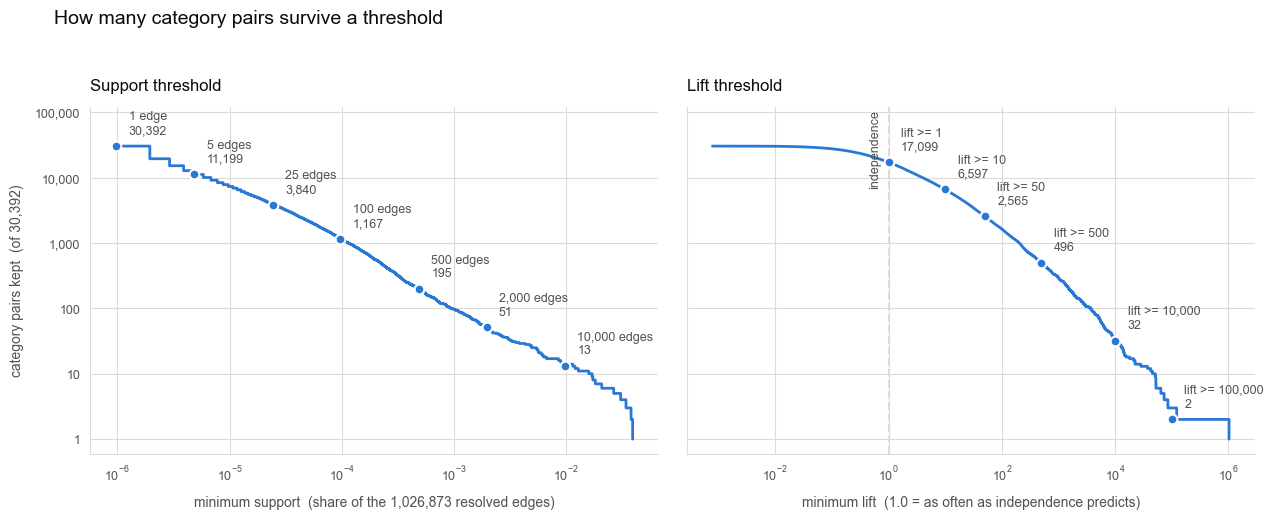

In [7]:
INK, INK_SOFT, GRID_LINE, SURFACE, SERIES = "#0b0b0b", "#52514e", "#dcdbd7", "#ffffff", "#2a78d6"


def survival(values):
    """Every distinct threshold, and how many pairs clear it."""
    ordered = np.sort(np.asarray(values))
    thresholds, first = np.unique(ordered, return_index=True)
    return thresholds, len(ordered) - first


def thin_marks(values, candidates, min_ratio=2.5):
    """Keep only candidates far enough apart on the curve to be labelled.

    Lift spans eight orders of magnitude, so a fixed list of round thresholds
    bunches its low end into one spot -- 1, 2 and 5 sit almost on top of each
    other. A candidate is kept only once the surviving count has fallen by
    `min_ratio` since the last one kept, which spaces the labels out on any
    distribution rather than on this one.
    """
    kept, last = [], None
    for mark in candidates:
        remaining = int((values >= mark).sum())
        if remaining == 0:
            break
        if last is None or remaining <= last / min_ratio:
            kept.append((mark, remaining))
            last = remaining
    return kept


def draw_survival(ax, values, candidates, mark_label, xlabel, title):
    x, y = survival(values)
    ax.step(x, y, where="post", color=SERIES, lw=2, solid_capstyle="round")

    # Direct labels at a few readable thresholds, not a number per point.
    for mark, remaining in thin_marks(values, candidates):
        ax.plot([mark], [remaining], "o", ms=7, color=SERIES,
                mec=SURFACE, mew=1.5, zorder=3, clip_on=False)
        ax.annotate(f"{mark_label(mark)}\n{remaining:,}",
                    (mark, remaining), textcoords="offset points", xytext=(9, 7),
                    fontsize=9, color=INK_SOFT, ha="left", va="bottom")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(top=y.max() * 4)  # headroom so the top label clears the title
    ax.set_xlabel(xlabel, fontsize=10, color=INK_SOFT, labelpad=8)
    ax.set_title(title, fontsize=12, color=INK, loc="left", pad=12)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_facecolor(SURFACE)  # explicit, so an ambient style cannot repaint it
    ax.grid(True, which="major", color=GRID_LINE, lw=0.8)
    ax.grid(False, which="minor")
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color(GRID_LINE)
    ax.tick_params(colors=INK_SOFT, labelsize=9)


fig, (ax_support, ax_lift) = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
fig.patch.set_facecolor(SURFACE)

# Support reads more naturally as an edge count, so the labelled thresholds are
# whole numbers of co-purchases converted to their share of the traffic.
EDGE_MARKS = [1, 5, 25, 100, 500, 2_000, 10_000]
draw_survival(
    ax_support,
    pair_stats["support"],
    candidates=[k / n_edges for k in EDGE_MARKS],
    mark_label=lambda t: f"{round(t * n_edges):,} edge" + ("s" if round(t * n_edges) > 1 else ""),
    xlabel=f"minimum support  (share of the {n_edges:,} resolved edges)",
    title="Support threshold",
)

LIFT_MARKS = [1, 2, 5, 10, 25, 50, 100, 500, 1_000, 10_000, 100_000]
ax_lift.axvline(1, color=GRID_LINE, lw=1.5, ls="--", zorder=1)
ax_lift.annotate("independence", (1, len(pair_stats) * 3.6), textcoords="offset points",
                 xytext=(-5, 0), fontsize=9, color=INK_SOFT, ha="right", va="top",
                 rotation=90)
draw_survival(
    ax_lift,
    pair_stats["lift"],
    candidates=LIFT_MARKS,
    mark_label=lambda t: f"lift >= {t:,g}",
    xlabel="minimum lift  (1.0 = as often as independence predicts)",
    title="Lift threshold",
)

ax_support.set_ylabel(f"category pairs kept  (of {len(pair_stats):,})",
                      fontsize=10, color=INK_SOFT, labelpad=8)
fig.suptitle("How many category pairs survive a threshold", fontsize=14,
             color=INK, x=0.045, ha="left", y=0.99)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

---

## Choosing the thresholds

Read the two numbers off the curves above, then open
`categories.ipynb` and type them into its threshold cell:

```python
MIN_EDGES = 5     # support floor, as a whole number of co-purchases
MIN_LIFT = 2.0
```

That notebook loads `data/pair_stats.pkl` — saved in §5 above — applies the
two, and writes `data/complementary_categories.pkl`. It does not re-read the raw
sources, so trying a different pair of thresholds costs seconds.

If the module's `threshold_grid` is wanted, it crosses ranges of both and adds
a column the curves do not show: how many source categories keep at least a
given number of pairs, so a cut whose survivors all hang off a few busy
categories is visible as such.

```python
from complementary_cats_pairs import threshold_grid
threshold_grid(pair_stats, edge_grid=(5, 10, 15, 25), lift_grid=(1.5, 2.0, 3.0))
```